# **Atividade Módulo 4 - Python para Preparação dos Dados**
- Yasmin Ramos Gusmão - FAP Análise de Dados 2026

# Base PRF 2025 agrupada por ocorrência

# Bloco 1 - Preparação do ambiente de trabalho

Importando bibliotecas e configurando ambiente

In [62]:
# Bloco de importação dos pacotes e bibliotecas fundamentais para a execução do pipeline de dados.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata
# Inclui ferramentas de alta performance para manipulação de tabelas e cálculos (Pandas e NumPy),
# geração de gráficos (Matplotlib), gerenciamento seguro de caminhos de arquivos (Pathlib),
# manipulação de variáveis de tempo (datetime) e padronização de caracteres e acentos (unicodedata).

# Bloco de configuração global do ambiente de exibição do Pandas no notebook.
# Como as bases de dados de acidentes costumam ter muitas variáveis, esses comandos
# aumentam os limites de renderização da tela, permitindo que o analista visualize
# até 120 colunas e uma largura maior de texto sem que a tabela seja "cortada" ou ocultada.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

Executando a criação de pastas

In [63]:
# Bloco de configuração e estruturação automatizada do ambiente do projeto.
# Define o diretório atual como raiz (".") e lista as pastas padrão necessárias para organizar
# O laço 'for' utiliza o método .mkdir() para criar cada pasta de forma segura:
RAIZ = Path(".")
PASTAS = [ "dados_brutos", "dados_tratados","notebooks", "sql", "dashboards", "relatorios", "apresentacao", "logs"]

for pasta in PASTAS:
  (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

# Bloco de validação e feedback visual.
# Imprime no console uma lista confirmando todos os caminhos (paths) das pastas
# que foram verificadas ou recém-criadas, garantindo que o ambiente está pronto.
print("Pastas verificadas/criadas:")
for pasta in PASTAS:
  print("-", RAIZ / pasta)

Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


Criando parâmetros antes da leitura dos dados.

In [64]:
# Bloco de configuração de diretórios e rotas de arquivos utilizando a biblioteca pathlib.
# Este bloco centraliza onde o código deve buscar o dado bruto e onde deve salvar todos os artefatos finais (bases tratadas e documentação).
ARQUIVO_BRUTO = Path("dados_brutos/dados_abertos_prf-datatran2025.csv")
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")

# Bloco de configuração de parâmetros para manipulação dos arquivos de texto (CSV).
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

# Bloco 2 - Leitura e primeira inspeção da base

Lendo o arquivo a partir da pasta dados_brutos.

In [65]:
# Define uma função robusta para importação do CSV que testa automaticamente diferentes codificações de texto (encodings).
def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
  ultimo_erro = None
  for enc in encodings:
    try:
      print(f"Tentando leitura com encoding={enc}...")
      return pd.read_csv(caminho, sep=sep, encoding=enc, low_memory=False)
    except Exception as erro:
      ultimo_erro = erro
      print(f"Falhou com {enc}: {erro}")
  raise ultimo_erro

# Executa a função customizada passando os parâmetros globais do projeto para carregar a base de dados
# e, em seguida, exibe as 5 primeiras linhas do DataFrame para garantir visualmente que a leitura foi um sucesso.
df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
df.head()

Tentando leitura com encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


Executando padronização e registrando a lista de colunas

In [66]:
# Função customizada para limpar e padronizar os nomes de todas as colunas do DataFrame
def normalizar_nome_coluna(nome):
    # Converte para texto, remove espaços nas extremidades e transforma tudo em letras minúsculas
    nome = str(nome).strip().lower()

    # Remove acentos e caracteres especiais utilizando a biblioteca unicodedata
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8", "ignore")

    # Substitui espaços em branco, hifens e barras por "underline" para evitar problemas de sintaxe no código
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")

    # Loop de segurança para garantir que não fiquem "underlines" seguidos
    while "__" in nome:
        nome = nome.replace("__", "_")

    # Remove qualquer "underline" residual que tenha sobrado no início ou no fim da string e retorna o resultado
    return nome.strip("_")

# Utiliza list comprehension para aplicar a função de normalização em massa, sobrescrevendo as colunas originais do DataFrame
df.columns = [normalizar_nome_coluna(c) for c in df.columns]

# Dicionário para forçar uma grafia específica
renomear = {"condicao_meteorologica": "condicao_metereologica"}

# Aplica a renomeação de forma segura: verifica antes se a coluna original (k) realmente existe na base, evitando erros
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

# Validação: exibe no console a lista final de colunas já tratadas e padronizadas
print(df.columns.tolist())

['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


Conferindo colunas esperadas

In [67]:
# Define uma lista com os nomes exatos das colunas que são essenciais e esperadas para o projeto
colunas_esperadas = [
    "data_inversa", "dia_semana", "horario", "uf", "br", "km", "municipio", "causa_acidente",
    "tipo_acidente", "classificacao_acidente", "fase_dia", "sentido_via", 'condicao_meteorologica', "tipo_pista",
    "tracado_via", "uso_solo", "pessoas", "mortos", "feridos_leves", "feridos_graves",
    "feridos", "veiculos"
]

# Utiliza list comprehension para cruzar as colunas esperadas com as que realmente existem no DataFrame (df.columns)
# Armazena na lista "faltantes" apenas os nomes que não foram encontrados na base de dados lida
faltantes = [c for c in colunas_esperadas if c not in df.columns]

# Exibe no console quais colunas estão faltando (o cenário ideal é retornar uma lista vazia)
print("Colunas faltantes:", faltantes)

# Condição de segurança: se a lista "faltantes" não estiver vazia (ou seja, se algo falhou na validação)
if faltantes:
    # Dispara um alerta que o arquivo base pode ter mudado de layout ou de versão
    print("Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")

Colunas faltantes: ['condicao_meteorologica']
Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.


Dimensão inicial da Base

In [68]:
# Exibe as dimensões totais do DataFrame no formato de tupla (
print("Dimensões:", df.shape)

# Acessa e exibe especificamente a quantidade de linhas
print("Linhas:", df.shape[0])

# Acessa e exibe especificamente a quantidade de colunas
print("Colunas:", df.shape[1])

# Exibe as 5 primeiras linhas do DataFrame para uma inspeção visual rápida do topo da tabela
display(df.head())

# Sorteia e exibe 5 linhas aleatórias da base para verificar a variedade das informações cadastradas
# O random_state=42 fixa uma "semente", garantindo que as mesmas 5 linhas sejam sorteadas todas as vezes que o código rodar (reprodutibilidade)
display(df.sample(5, random_state=42))

Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


#Bloco 3 - Diagnóstico de qualidade dos dados
Identificando os tipos dos dados

In [69]:
# Exibe um panorama técnico completo do DataFrame
# O parâmetro memory_usage="deep" força o Pandas a calcular o consumo real e exato de memória RAM da base,
# inspecionando detalhadamente o peso das colunas de texto (object/string)
df.info(memory_usage="deep")

# Cria um quadro consolidado para auditar a tipagem da base de dados
resumo_tipos = (
    # Extrai os tipos de dados de todas as colunas e os converte para formato de texto
    df.dtypes.astype(str)

    # Conta a frequência de cada tipo encontrado
    .value_counts()

    # Renomeia o índice da série para "tipo"
    .rename_axis("tipo")

    # Transforma o resultado agrupado de volta em uma tabela,
    # batizando a nova coluna de contagem como "qtd_colunas"
    .reset_index(name="qtd_colunas")
)

# Exibe na tela a tabela com o resumo estrutural dos tipos de dados do projeto
display(resumo_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


Gerando tabela de nulos

In [70]:
# Cria um novo DataFrame contendo um relatório consolidado sobre os dados ausentes da base
nulos = pd.DataFrame({
    # Calcula a quantidade absoluta de valores vazios em cada coluna
    "qtd_nulos": df.isna().sum(),

    # Calcula a proporção de vazios e multiplica por 100 para transformar em percentual
    "perc_nulos": df.isna().mean() * 100

# Ordena o relatório final de forma decrescente, colocando no topo as colunas com a maior taxa de dados faltantes
}).sort_values("perc_nulos", ascending=False)

# Exibe o relatório na tela, filtrando para mostrar APENAS as colunas que possuem pelo menos 1 valor nulo
# (Oculta as colunas que estão 100% preenchidas para focar no que precisa de tratamento)
display(nulos[nulos["qtd_nulos"] > 0])

,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


Diagnóstico e Remoção de duplicidades

In [71]:
# Avalia o DataFrame inteiro para identificar linhas idênticas e soma o total de ocorrências
qtd_duplicadas = df.duplicated().sum()

# Exibe no console a quantidade exata de linhas duplicadas encontradas
print("Duplicidades exatas:", qtd_duplicadas)

# Condição lógica de checagem: se o número de linhas duplicadas for maior que zero, inicia o processo de limpeza
if qtd_duplicadas > 0:

    # Remove as duplicidades e atualiza o DataFrame com uma cópia limpa
    df = df.drop_duplicates().copy()

    # Exibe uma mensagem de confirmação junto com as novas dimensões da base de dados após a exclusão
    print("Duplicidades removidas. Nova dimensão:", df.shape)

Duplicidades exatas: 0


Gerando cardinalidade das categorias

In [72]:
# Identifica e salva uma lista apenas com os nomes das colunas de texto/categóricas
categoricas = df.select_dtypes(include="object").columns

# Calcula a cardinalidade (quantidade de valores únicos) de cada coluna textual
cardinalidade = (
    df[categoricas]
    # Conta os valores únicos distintos de cada coluna, ignorando os valores nulos na contagem
    .nunique(dropna=True)
    # Ordena os resultados em ordem decrescente, destacando as colunas com mais categorias
    .sort_values(ascending=False)
    # Converte o resultado de volta para o formato de tabela
    .reset_index()
)

# Renomeia as colunas da nova tabela gerada para deixar o relatório mais claro e descritivo
cardinalidade.columns = ["variavel", "qtd_categorias"]

# Exibe na tela as 30 colunas textuais que possuem a maior variedade de categorias (maior cardinalidade)
display(cardinalidade.head(30))

,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [73]:
# Acessa o atributo '.shape' para verificar as dimensões da estrutura de dados 'cardinalidade'
# Retorna o tamanho atual da tabela em formato de tupla, mostrando: (quantidade_de_linhas, quantidade_de_colunas)
cardinalidade.shape

(20, 2)

#Bloco 4 - Transformações e criação de variáveis derivadas

Convertendo colunas numéricas

In [74]:
# Define uma lista contendo os nomes das colunas que obrigatoriamente devem ser tratadas como números
colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves", "feridos_graves", "ilesos", "ignorados", "veiculos"
]

# Itera sobre a lista de colunas numéricas
for coluna in colunas_numericas:
    # Verifica de forma segura se a coluna existe no DataFrame, evitando erros caso a base mude
    if coluna in df.columns:

        # Força a conversão do conteúdo da coluna para o formato numérico
        # O errors="coerce" é uma trava de segurança: se encontrar um texto onde deveria ter um número,
        # ele transforma esse erro em um valor nulo em vez de quebrar a execução do programa
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

# Filtra as colunas numéricas que existem na base e imprime os seus tipos de dados (.dtypes)
# O objetivo esperado é que todas retornem tipos como 'float64' ou 'int64'
print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


Tratando datas e criando variáveis temporais

In [75]:
# Converte a coluna de data para o tipo oficial de data/hora do Pandas (datetime)
# O errors="coerce" força valores com formatos inválidos a virarem nulos (NaT), evitando que o código quebre
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")

# Utiliza o acessor ".dt" para extrair pedaços específicos da data e criar novas colunas para análise
df["ano"] = df["data_inversa"].dt.year          # Extrai o ano
df["mes"] = df["data_inversa"].dt.month         # Extrai o mês
df["trimestre"] = df["data_inversa"].dt.quarter # Extrai o trimestre do ano

# Extrai o dia da semana em formato numérico, onde Segunda-feira é 0 e Domingo é 6
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek

# Cria um indicador binário para marcar se o acidente ocorreu no fim de semana
# Verifica se o dia é Sábado ou Domingo e converte o resultado lógico para número inteiro
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

# Exibe as 5 primeiras linhas com a data original e as novas variáveis derivadas para conferência
display(df[["data_inversa", "ano", "mes", "trimestre", "dia_semana_num", "fim_de_semana"]].head())

,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


Tratando horário e criando turnos

In [76]:
# Garante que a coluna original seja texto e remove espaços em branco acidentais nas extremidades
horario_limpo = df["horario"].astype(str).str.strip()

# Tenta converter os textos para formato de tempo (Hora:Minuto:Segundo) e extrai apenas o valor da hora inteira (.dt.hour)
# O errors="coerce" faz com que os formatos que não derem "match" virem nulo (NaN) em vez de travar o código
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

# Cria uma máscara condicional isolando apenas os registros em que a extração acima falhou (ficaram nulos)
faltou_hora = df["hora"].isna()

# Se houve alguma falha, tenta extrair a hora novamente APENAS nas linhas com erro,
# assumindo agora que o dado pode ter vindo incompleto, apenas com Hora e Minuto (HH:MM)
if faltou_hora.any():
  df.loc[faltou_hora, "hora"] = pd.to_datetime(horario_limpo[faltou_hora], format="%H:%M", errors="coerce").dt.hour


# Função de negócio para categorizar a hora extraída em grandes blocos (turnos do dia)
def classificar_turno(hora):
  # Tratamento de erro: se a hora for nula/inválida, sinaliza a informação como não disponível
  if pd.isna(hora):
    return "IGNORADO"
  # Regras de agrupamento: Madrugada (00h-05h), Manhã (06h-11h), Tarde (12h-17h) e o restante é Noite
  if 0 <= hora <= 5:
    return "MADRUGADA"
  if 6 <= hora <= 11:
    return "MANHÃ"
  if 12 <= hora <= 17:
    return "TARDE"
  return "NOITE"

# Aplica a função linha a linha na coluna "hora" e salva o resultado final na nova coluna "turno"
df["turno"] = df["hora"].apply(classificar_turno)

# Validação visual: exibe as 5 primeiras linhas mostrando a evolução completa:
# formato original (horario) -> extração numérica (hora) -> agrupamento de negócio (turno)
display(df[["horario", "hora", "turno"]].head())

,horario,hora,turno
0,06:20:00,6,MANHÃ
1,07:50:00,7,MANHÃ
2,08:45:00,8,MANHÃ
3,11:00:00,11,MANHÃ
4,09:30:00,9,MANHÃ


Criando faixas de horários e conferindo distribuição

In [77]:
# Função para agrupar as horas exatas em blocos de 3 em 3 horas
def criar_faixa_horaria(hora):

    # Trata valores ausentes/nulos atribuindo a categoria textual "IGNORADO"
    if pd.isna(hora):
        return "IGNORADO"

    # Calcula a hora de início da faixa usando divisão inteira
    inicio = int(hora // 3) * 3

    # Calcula o fim da faixa somando 2 horas ao limite inicial
    fim = inicio + 2

    # Retorna a string formatada garantindo 2 dígitos com zero à esquerda
    return f"{inicio:02d}h-{fim:02d}h"

# Aplica a função linha a linha na coluna "hora" e salva o resultado na nova coluna "faixa_horaria"
df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)

# Conta e exibe a quantidade de acidentes em cada faixa horária (incluindo possíveis nulos)
# O .sort_index() organiza a exibição em ordem cronológica
display(df["faixa_horaria"].value_counts(dropna=False).sort_index())

,count
faixa_horaria,
00h-02h,3959
03h-05h,4948
06h-08h,11517
09h-11h,9342
12h-14h,9678
15h-17h,12624
18h-20h,13473
21h-23h,6988


Padronizando colunas textuais


In [78]:
# Identifica e armazena os nomes de todas as colunas do tipo texto (geralmente lidas como "object")
colunas_texto = df.select_dtypes(include="object").columns

# Itera sobre cada coluna de texto identificada na lista acima
for coluna in colunas_texto:

    # 1. Converte o dado explicitamente para o tipo 'string' do Pandas
    # 2. Remove espaços em branco acidentais no início ou no fim do texto (.str.strip())
    # 3. Padroniza todas as letras para MAIÚSCULAS (.str.upper())
    df[coluna] = (
        df[coluna].astype("string").str.strip().str.upper()
    )

    # Identifica falsos nulos (textos como "NAN", "NULL" ou apenas espaços vazios que sobraram)
    # e os substitui pelo marcador oficial de valor ausente do Pandas (pd.NA)
    df[coluna] = df[coluna].replace({" ": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})

# Validação: exibe no console a quantidade total de colunas que passaram por essa padronização
print("Colunas textuais padronizadas:", len(colunas_texto))


Colunas textuais padronizadas: 20


Preenchendo categorias importantes e conferindo nulos remanescentes



In [79]:
# Lista de colunas categóricas que precisam de tratamento
categoricas_importantes = [
  "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia",
  "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
  "classificacao_acidente", "dia_semana"
]

# Itera sobre a lista de colunas selecionadas
for coluna in categoricas_importantes:
  # Verifica se a coluna existe no DataFrame para evitar erros
  if coluna in df.columns:
    # Substitui valores nulos por "IGNORADO", evitando deletar a linha inteira
    df[coluna] = df[coluna].fillna("IGNORADO")

# Validação: exibe a quantidade de nulos restantes nessas colunas (espera-se 0)
print(df[categoricas_importantes].isna().sum().sort_values(ascending=False))

uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


Preenchendo nulos em contagens

In [80]:
# Lista de colunas numéricas referentes a contagens
contagens_vitimas = ["mortos", "feridos", "feridos_leves", "feridos_graves", "pessoas", "veiculos"]

# Itera sobre a lista de colunas de contagem
for coluna in contagens_vitimas:
  # Verifica se a coluna existe no DataFrame para evitar erros
  if coluna in df.columns:
    # Substitui nulos por 0, assumindo que ausência de dado significa zero ocorrências
    df[coluna] = df[coluna].fillna(0)

# Validação: exibe a quantidade de nulos restantes (usando list comprehension para checar apenas colunas existentes)
print(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())

mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


# Bloco 5 - Variável-alvo e indicadores de gravidade

Criando acidente_fatal e Conferindo distribuição absoluta e percentual

In [81]:
# Cria a variável alvo e atribui 1 se houver 1 ou mais mortos, caso contrário, atribui 0
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)

# Cria um DataFrame resumo contando a frequência de acidentes fatais e não fatais
validacao_alvo = \
df["acidente_fatal"].value_counts(dropna=False).rename_axis("acidente_fatal").reset_index(name="qtd")

# Calcula e adiciona uma coluna de porcentagem ("perc") com a representatividade de cada categoria
validacao_alvo["perc"] = validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100

# Exibe a tabela de validação na tela
display(validacao_alvo)

,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


Executando teste lógico e registrando o resultado

In [82]:
# Filtra o DataFrame para encontrar inconsistências lógicas na variável alvo
# Casos inválidos: ter 1 ou mais mortos e NÃO ser fatal, OU ter 0 mortos e NÃO ser não-fatal
violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]

# Imprime a quantidade de registros que violaram a regra estabelecida
print("Violações da regra do alvo:", len(violacoes))

# Validação final: trava a execução do código (retorna erro) caso seja encontrada alguma violação
assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."

Violações da regra do alvo: 0


Criando indicadores de gravidade e conferindo a amostra

In [83]:
# Cria uma nova coluna consolidando o total de vítimas (soma de mortos, feridos leves e graves)
df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]

# Cria um indicador binário (1 ou 0) para classificar o acidente como grave
# Atribui 1 se houver pelo menos um morto OU pelo menos um ferido grave; caso contrário, 0
df["acidente_grave"] = np.where(
    (df["mortos"] >= 1) | (df["feridos_graves"] >= 1),
    1,
    0
)

# Calcula um índice de gravidade ponderado para cada acidente com base no tipo de vítima
# Pesos: Mortos = 3, Feridos Graves = 2, Feridos Leves = 1
df["indice_gravidade"] = (
    df["mortos"] * 3
    + df["feridos_graves"] * 2
    + df["feridos_leves"]
)

# Exibe as 5 primeiras linhas das colunas criadas e utilizadas para conferir os cálculos
display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "indice_gravidade"]].head())

,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


Criar br_formatada e chave_localidade

In [84]:
# Função para padronizar a nomenclatura das rodovias
def formatar_br(valor):
    # Trata valores nulos (NaN) ou iguais a zero marcando a informação como ignorada
    if pd.isna(valor) or valor == 0:
        return "BR-IGNORADA"
    # Formata o número da rodovia garantindo 3 dígitos com zeros à esquerda (ex: 4 vira "BR-004")
    return f"BR-{int(valor):03d}"

# Aplica a função linha a linha na coluna "br" e salva o resultado na nova coluna "br_formatada"
df["br_formatada"] = df["br"].apply(formatar_br)

# Cria um identificador (chave) único de localidade concatenando Estado, Município e BR
# O .astype(str) garante que todos os dados sejam tratados como texto para usar o separador "_"
df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str)
)

# Exibe as 5 primeiras linhas das colunas geográficas para conferência
display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head())

,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251


Executando checagens e comparando com expectativas iniciais

In [85]:
# Cria um dicionário para armazenar métricas consolidadas e auditar o dataset
checagens = {
    # Conta a dimensão geral dos dados: total de registros (linhas) e variáveis (colunas)
    "linhas": len(df),
    "colunas": df.shape[1],

    # Soma o total de acidentes classificados como fatais (onde o valor é 1) e converte para inteiro
    "acidentes_fatais": int(df["acidente_fatal"].sum()),

    # Calcula a proporção de acidentes fatais em relação ao todo (média de uma variável binária)
    "taxa_fatalidade": float(df["acidente_fatal"].mean()),

    # Consolida a quantidade absoluta de vítimas fatais em todo o dataset
    "total_mortos": int(df["mortos"].sum()),

    # Uso de condicional em uma linha: calcula o total de feridos APENAS se a coluna existir, evitando erros
    "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
}

# Exibe o dicionário gerado com o resumo geral das informações
checagens

{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 0.07183333563126473,
 'total_mortos': 6043,
 'total_feridos': 83550}

Gerando ranking de causa_acidente e tipo_acidente

In [86]:
# Cria uma função reutilizável para gerar o top 'n' das categorias mais frequentes de uma coluna
def ranking_categoria(base, coluna, n=10):
    return (
        base[coluna]
        # Conta a frequência de cada valor único, mantendo os valores nulos na contagem
        .value_counts(dropna=False)
        # Filtra para manter apenas os 'n' primeiros colocados do ranking
        .head(n)
        # Ajusta o nome do eixo do índice para corresponder ao nome da coluna analisada
        .rename_axis(coluna)
        # Converte a Série em um DataFrame estruturado, nomeando a coluna de contagens como "qtd"
        .reset_index(name="qtd")
    )

# Aplica a função e exibe o ranking das 10 principais "causas de acidente"
display(ranking_categoria(df, "causa_acidente", 10))

# Aplica a função e exibe o ranking dos 10 principais "tipos de acidente"
display(ranking_categoria(df, "tipo_acidente", 10))

,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


Calculando taxa fatal por tipo_acidente com mínimo de 30 registros

In [87]:
# Função para calcular a taxa de letalidade de uma categoria, exigindo um volume mínimo de dados
def taxa_fatal_por_categoria(base, coluna, min_registros=30):

    # Agrupa os dados pela coluna informada e gera três novas métricas consolidadas
    tab = base.groupby(coluna).agg(
        qtd_acidentes=("acidente_fatal", "size"), # Conta o total de acidentes (volume total da categoria)
        qtd_fatais=("acidente_fatal", "sum"),     # Soma apenas os acidentes marcados como fatais
        taxa_fatal=("acidente_fatal", "mean")     # Calcula a proporção (média) de acidentes fatais
    ).reset_index()                               # Converte o índice de agrupamento de volta em coluna

    # Filtra a tabela removendo categorias com poucas ocorrências para evitar distorções estatísticas
    tab = tab[tab["qtd_acidentes"] >= min_registros]

    # Retorna o DataFrame final ordenado pela maior taxa de letalidade (ordem decrescente)
    return tab.sort_values("taxa_fatal", ascending=False)

# Aplica a função analisando a coluna "tipo_acidente" e exibe o top 10 das categorias mais letais
display(taxa_fatal_por_categoria(df, "tipo_acidente", min_registros=30).head(10))

,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃO FRONTAL,4739,1396,0.294577
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÍPICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
3,COLISÃO COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃO TRANSVERSAL,9306,427,0.045884
8,COLISÃO TRASEIRA,14360,619,0.043106


Gerando gráfico de acidente_fatal

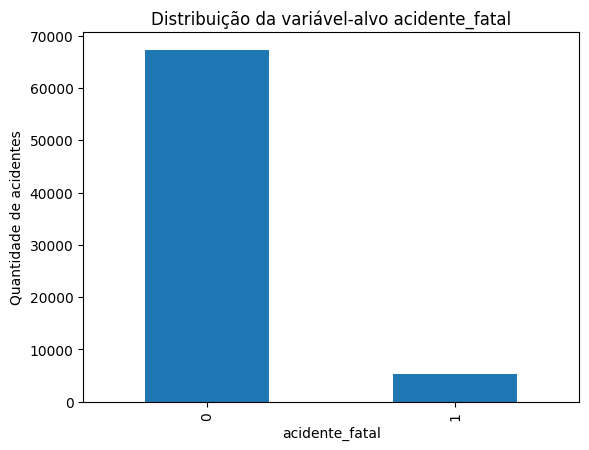

In [88]:
# Conta a frequência da variável alvo, ordena pelo índice e gera um gráfico de barras
ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")

# Define o título principal do gráfico para contextualizar a visualização
ax.set_title("Distribuição da variável-alvo acidente_fatal")

# Adiciona um rótulo descritivo para o eixo X (horizontal) indicando a categoria
ax.set_xlabel("acidente_fatal")

# Adiciona um rótulo descritivo para o eixo Y (vertical) indicando a métrica contada
ax.set_ylabel("Quantidade de acidentes")

# Renderiza e exibe o gráfico finalizado na tela
plt.show()

#Bloco 6 - Construção das bases analítica e modelável

Criando base_analítica e verificando dimensões

In [89]:
# Cria uma cópia independente do DataFrame original para evitar alterações indesejadas na base de origem
base_analitica = df.copy()

# Exibe as dimensões da nova base de dados (quantidade de linhas e colunas)
print("Base analítica:", base_analitica.shape)

# Extrai e exibe o nome de todas as colunas da base analítica em formato de lista
print("Colunas:", base_analitica.columns.tolist())

Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']


Criando base_modelável com variáveis permitidas

In [90]:
# Define uma lista com as colunas (features explicativas e a variável-alvo) que farão parte do modelo
variaveis_modelaveis = [
    "uf", "br_formatada", "municipio", "mes", "trimestre",
    "dia_semana", "dia_semana_num", "fim_de_semana",
    "hora", "faixa_horaria", "turno", "fase_dia",
    "causa_acidente", "tipo_acidente", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
    "acidente_fatal"
]

# Filtra a lista garantindo que apenas as colunas que realmente existem no DataFrame sejam mantidas
variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]

# Cria um novo DataFrame exclusivo para a modelagem, contendo apenas as colunas filtradas
# O .copy() é usado para criar uma base independente, evitando alterar os dados originais sem querer
base_modelavel = df[variaveis_modelaveis].copy()

# Exibe as dimensões (quantidade de linhas e colunas) da nova base pronta para uso
print("Base modelável:", base_modelavel.shape)

Base modelável: (72529, 19)


Executando verificação de leakage e registrando OK

In [91]:
# Lista de variáveis que revelam o resultado do acidente
# Essas colunas não podem estar no modelo, pois são consequências do evento e não estarão disponíveis no momento da previsão
variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves",
    "total_vitimas", "indice_gravidade", "acidente_grave",
    "classificacao_acidente"
]

# Função de segurança para auditar se há vazamento de dados no DataFrame final
def verificar_data_leakage(base, proibidas):
    # Verifica quais variáveis da lista de proibidas acabaram "vazando" para as colunas da base
    presentes = [c for c in proibidas if c in base.columns]

    # Se encontrar pelo menos uma variável proibida, trava a execução do código com um erro estrutural (ValueError)
    if presentes:
        raise ValueError(f"Data leakage detectado: {presentes}")

    # Se a validação não encontrar problemas, retorna uma mensagem confirmando que a base está segura
    return "OK - nenhuma variável proibida encontrada."

# Aplica a função de checagem na base de modelagem, utilizando a lista de regras de bloqueio
verificar_data_leakage(base_modelavel, variaveis_proibidas)

'OK - nenhuma variável proibida encontrada.'

Tratando nulos remanescentes na base_modelável

In [92]:
# Itera sobre todas as colunas da base de dados preparada para o modelo
for coluna in base_modelavel.columns:

    # Pula o tratamento para a variável-alvo, garantindo que o que queremos prever não seja alterado
    if coluna == "acidente_fatal":
        continue

    # Se a coluna for de texto (categórica), preenche os valores nulos (ausentes) com a string "IGNORADO"
    if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string":
        base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")

    # Caso contrário (colunas numéricas), preenche os nulos com o valor -1
    # O -1 é usado como uma marcação (flag) para que o algoritmo entenda que a informação estava ausente
    else:
        base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)

# Validação: confere se sobrou algum nulo, exibindo as 5 colunas com mais valores vazios (o esperado é que todas retornem 0)
print(base_modelavel.isna().sum().sort_values(ascending=False).head())

uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64


Exportando base analítica e base modelável

In [93]:
# Exporta o DataFrame de análise (com todas as variáveis tratadas) para um arquivo CSV
# sep e encoding utilizam variáveis globais para padronizar o delimitador e a codificação de caracteres
base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

# Exporta o DataFrame de modelagem (apenas variáveis selecionadas) para outro arquivo CSV
# Segue os mesmos padrões de formatação definidos acima para manter a consistência do projeto
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

# Exibe no console uma mensagem de confirmação informando que o processo terminou
# Lista os nomes/caminhos dos arquivos recém-criados para facilitar a localização
print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

Arquivos exportados:
- dados_tratados/base_analitica_prf_2025.csv
- dados_tratados/base_modelavel_prf_2025.csv


Reabrindo as bases e validando dimensões

In [94]:
# Lê os arquivos CSV recém-exportados para realizar uma validação de integridade
# Utiliza os mesmos parâmetros (separador e encoding) para garantir a leitura correta dos dados
valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)

# Exibe as dimensões das bases recarregadas para conferência visual
print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)

# Validação estrutural rigorosa: trava a execução do código caso a quantidade
# de linhas do arquivo salvo não seja exatamente igual à da base original mantida em memória
assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)

Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)


#Bloco 7 - Documentação do Projeto

Gerando dicionario_variaveis_modulo4.csv

In [95]:
# Cria uma lista de dicionários contendo os metadados (dicionário de dados) das novas variáveis criadas
# Documenta o nome da variável, a regra de cálculo (descrição) e a sua finalidade (uso) no projeto
linhas_dic = [
    {"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso": "alvo"},
    {"variavel": "total_vitimas", "descricao": "mortos + feridos leves + feridos graves", "uso": "analise/dashboard"},
    {"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves", "uso": "analise/dashboard"},
    {"variavel": "br_formatada", "descricao": "BR padronizada no formato BR-000", "uso": "analise/modelagem"},
    {"variavel": "chave_localidade", "descricao": "UF + município + BR formatada", "uso": "analise/dashboard"},
]

# Converte a lista de dicionários em um DataFrame (tabela) estruturado do Pandas
dicionario = pd.DataFrame(linhas_dic)

# Exporta o dicionário de dados para um arquivo CSV, servindo como documentação externa de apoio
# Utiliza os mesmos parâmetros padronizados de separador e encoding do restante do projeto
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

# Exibe a tabela do dicionário de dados gerado na tela para conferência visual
display(dicionario)

,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


Criando arquivo de decisões em logs

In [96]:
# Cria uma string formatada (f-string) em formato Markdown para documentar as regras de negócio e transformações aplicadas
# Utiliza chaves {} para injetar variáveis dinâmicas, como a data/hora exata da execução e os nomes dos arquivos gerados
texto_decisoes = f"""
# Decisões de tratamento — Módulo 4

Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões
- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.

## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""

# Salva o relatório de documentação em um arquivo de texto, usando a codificação "utf-8" para preservar acentuações e caracteres especiais
ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")

# Exibe o caminho e o nome do arquivo gerado no console como confirmação visual de que o log foi salvo com sucesso
print(ARQUIVO_DECISOES)

logs/decisoes_tratamento_modulo4.md


Criando README.md e revisando conteúdo

In [97]:
# Cria uma string formatada (f-string) em formato Markdown para estruturar a documentação principal (README) do projeto
# Detalha o objetivo geral, a regra da variável-alvo, as bases geradas e as observações metodológicas do pipeline
readme = f"""
# Projeto PRF 2025 — Preparação dos Dados

## Objetivo
Preparar os dados de acidentes da PRF 2025 para análise exploratória, Power BI e árvore de
decisão explicável.

## Variável-alvo
`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.

## Bases geradas
- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.

## Observação metodológica
A base modelável exclui mortos, feridos, total_vitimas, indice_gravidade e variáveis diretamente
derivadas do desfecho.
"""

# Grava o conteúdo estruturado do README em um arquivo físico, utilizando a codificação "utf-8" para suporte a acentuação
ARQUIVO_README.write_text(readme, encoding="utf-8")

# Exibe uma mensagem no console confirmando que o arquivo README foi criado com sucesso e mostrando seu caminho
print("README criado:", ARQUIVO_README)

README criado: README.md


Gerando resumo final no notebook

In [98]:
# Cria um DataFrame de resumo consolidando os números finais do projeto
# Estrutura uma tabela com o nome do indicador ("item") e seu respectivo cálculo ("valor")
# Registra o volume de dados (linhas e colunas) das duas bases geradas e a proporção geral da variável-alvo
resumo_final = pd.DataFrame([
    {"item": "linhas_base_analitica", "valor": len(base_analitica)},
    {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
    {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
    {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
    {"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()},
])

# Exibe a tabela de resumo formatada na tela para validação visual dos resultados
display(resumo_final)

,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.071833
